# EDA Contribution - Michael Valderrama

**Author:** Michael Valderrama
**Course:** AAI-500 - Statistics and Probability for Artificial Intelligence (Final Team Project)
**School:** University of San Diego - Master of Science in Applied Artificial Intelligence
**Date:** 06-05-26

My two EDA pieces for the SUPPORT2 final project, as a standalone notebook: a
univariable signal screen (which day-3 features separate survived from died on
their own) and an imputation check (whether missingness was tied to the outcome,
for the Limitations write-up). Both run on the team's cleaned dataset via Tue's
utils.dataset.load_csv; the imputation check also reads the raw table to recover
the original missing pattern.

In [1]:
# standalone setup: put the repo root on sys.path so Tue's utils package imports
import sys
from pathlib import Path

_here = Path.cwd().resolve()
_root = _here if (_here / "utils").exists() else _here.parents[1]
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

For my part of the swarm I went after the two EDA pieces that connect most directly to what
we do next: a univariable screen to help narrow the variables for model selection, and a
missingness check to cover the missing-data note for the Limitations section. Both are quick,
but they're the two I could see tying straight into the modeling and the paper.

## 1. Univariable signal screen

A preliminary look at how strongly each day-3 variable, on its own, is associated with
180-day mortality (rank-based AUROC, 0.50 = chance). Variable set not final.

sps        0.68
aps        0.66
scoma      0.62
age        0.56
hrt        0.54
meanbp     0.54
alb        0.54
bili       0.53
pafi       0.53
crea       0.53
wblc       0.52
resp       0.52
temp       0.51
bun        0.51
sod        0.51
glucose    0.51
ph         0.50


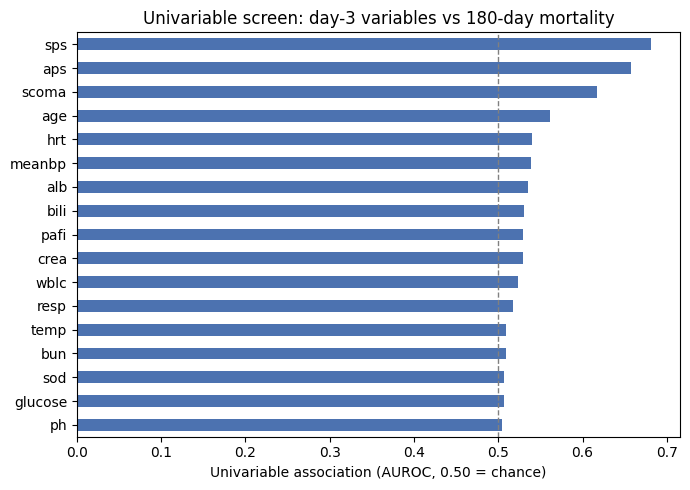

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.dataset import load_csv

df = load_csv("support2_cleaned.csv")
y = df["death_180d"]
variables = [
    "aps",
    "sps",
    "scoma",
    "age",
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "wblc",
    "crea",
    "bili",
    "alb",
    "pafi",
    "bun",
    "sod",
    "ph",
    "glucose",
]
variables = [v for v in variables if v in df.columns]


def univariable_auroc(x, y):
    ranks = pd.Series(x).rank().values
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    auc = (ranks[y.values == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return max(auc, 1 - auc)


scores = pd.Series({v: univariable_auroc(df[v], y) for v in variables}).sort_values(
    ascending=False
)
print(scores.round(2).to_string())

scores[::-1].plot.barh(figsize=(7, 5), color="#4C72B0")
plt.axvline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Univariable association (AUROC, 0.50 = chance)")
plt.title("Univariable screen: day-3 variables vs 180-day mortality")
plt.tight_layout()
plt.show()

Severity composites lead (sps 0.68, aps 0.66, scoma 0.62); single vitals and labs are weak
alone (0.50 to 0.54). sps and aps seem to be correlated, so maybe we only need one? So for
model selection, my read is to lean on one severity composite plus age and disease group as
the base, and bring the individual labs (albumin, bilirubin, creatinine, white count) in to
test for added value rather than starting with all of them.

## 2. Imputation check

A few columns were heavily imputed (glucose, albumin, bilirubin, 25 to 49 percent), while
creatinine and white count were barely touched. This documents the missingness for the
Limitations section and checks that it is unrelated to the outcome, the missing-at-random
assumption our models rely on.

In [3]:
raw = load_csv("support2_raw_complete.csv")
dtime = "d.time" if "d.time" in raw.columns else "d_time"
y_raw = ((raw["death"] == 1) & (raw[dtime] <= 180)).astype(int)

report = []
for col in ["alb", "bili", "pafi", "glucose", "wblc", "crea"]:
    if col not in raw.columns:
        continue
    m = raw[col].isna()
    report.append(
        {
            "variable": col,
            "pct_imputed": round(m.mean() * 100, 1),
            "gap": round(y_raw[m].mean() - y_raw[~m].mean(), 2),
        }
    )
print(
    pd.DataFrame(report)
    .sort_values("pct_imputed", ascending=False)
    .to_string(index=False)
)

variable  pct_imputed   gap
 glucose         49.4  0.02
     alb         37.0  0.00
    bili         28.6 -0.02
    pafi         25.5 -0.03
    wblc          2.3 -0.03
    crea          0.7  0.05


Across the columns, the mortality gap between the originally-missing and originally-present
rows stayed within 0.05 (the largest, creatinine at 0.05, is basically noise since only 0.7
percent was missing). The heavily-imputed columns (glucose, albumin, bilirubin) show no link
between being missing and dying, so the imputation looks safe to model on. Goes in the
Limitations note.